In [1]:
import sys
sys.path.append("..")

In [2]:
import numpy as np
from feature_analysis.feature_extract import FeatureExtractManager

In [3]:
kernels_dataset = np.load("../Kernels_datasets_numpy/kernel_dataset_2.npy", allow_pickle=True).item()
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


In [4]:
feature_list = ['variance', 'glcm_correlation',     # Obtenida de análisis preliminares
                'energy_1st', 'glcm_entropy', 
                'skewness','kurtosis']


--- RANKING DE CARACTERÍSTICAS ---
        Caracteristica  Score_Final  Info_Mutua  RF_Importancia
0             variance     0.998016    0.320449        0.125921
1     glcm_correlation     0.990811    0.314559        0.126422
2           energy_1st     0.604947    0.159801        0.089913
3         glcm_entropy     0.585415    0.190325        0.072933
4              mean_hu     0.559064    0.137268        0.087202
5             kurtosis     0.535265    0.154449        0.074406
6             skewness     0.498188    0.091072        0.090035
7          glcm_energy     0.471212    0.161924        0.055262
8    ldop_grad_90_mean     0.352738    0.090701        0.053405
9     glcm_homogeneity     0.289122    0.051737        0.052692
10   ldop_grad_45_mean     0.282477    0.071143        0.043356
11       glcm_contrast     0.264903    0.050258        0.047152
12  ldop_grad_135_mean     0.263971    0.055959        0.044667
13    ldop_grad_0_mean     0.228609    0.053654        0.036635


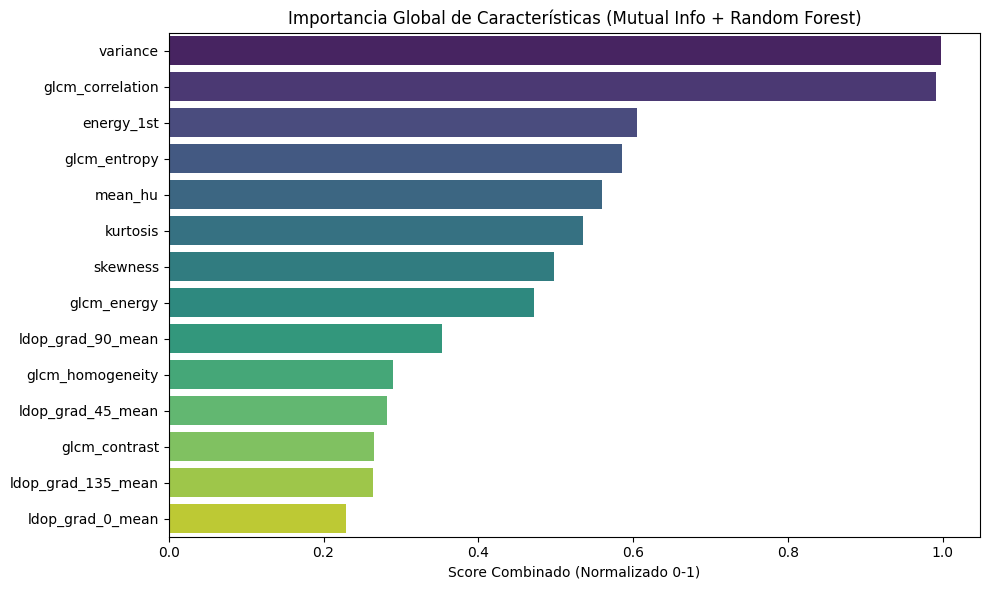

Calculando matriz de correlación cruzada...


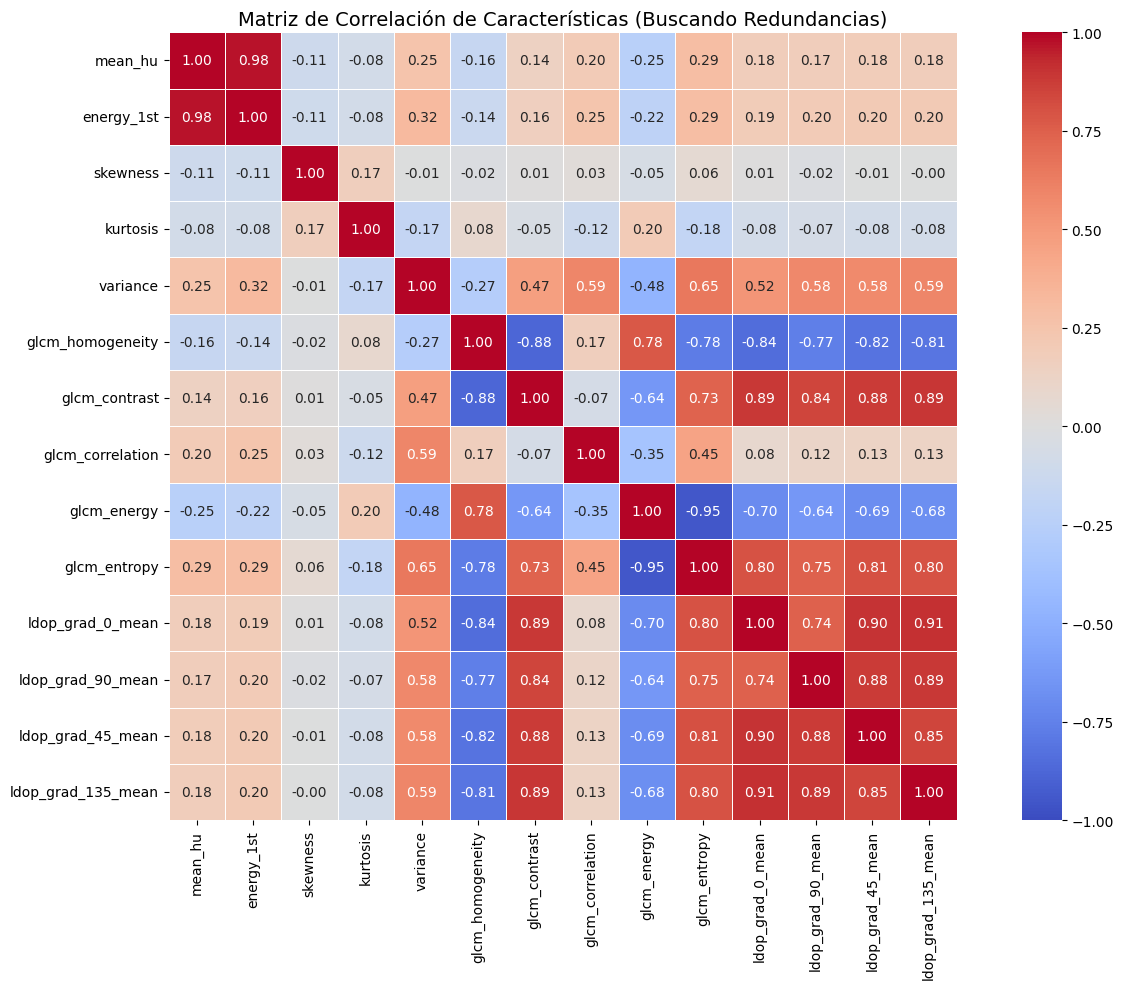

In [11]:
from feature_evaluation.feature_evaluator import FeatureEvaluator
evaluator = FeatureEvaluator(df_features, analysis=True)

In [6]:
ranking = evaluator.rank_feature_combinations(feature_list, max_size=6)

Analizando combinaciones de '['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']'...

--- TOP 5 MEJORES COMBINACIONES ---
    num_features                                           features  accuracy
62             6  variance, glcm_correlation, energy_1st, glcm_e...  0.781051
61             5  glcm_correlation, energy_1st, glcm_entropy, sk...  0.775852
58             5  variance, glcm_correlation, energy_1st, skewne...  0.772386
56             5  variance, glcm_correlation, energy_1st, glcm_e...  0.771808
60             5  variance, energy_1st, glcm_entropy, skewness, ...  0.771808
51             4  glcm_correlation, energy_1st, glcm_entropy, sk...  0.770653
42             4   variance, glcm_correlation, energy_1st, skewness  0.753899
57             5  variance, glcm_correlation, energy_1st, glcm_e...  0.750433
47             4       variance, energy_1st, glcm_entropy, skewness  0.750433
49             4           variance, energy_1st, skewness, kurt

In [9]:
best_features_kernel_1 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_1)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.59%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.72%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 50.20%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 49.22%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.59% de precisión.


In [10]:
best_features_kernel_2 = ['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_2)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.87%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.83%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 50.14%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 53.55%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.87% de precisión.


In [12]:
best_features_kernel_3 = ['variance', 'glcm_correlation', 'energy_1st', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_3)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.47%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.78%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 50.20%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 53.50%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.47% de precisión.


In [13]:
best_features_kernel_4 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_4)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.59%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.72%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 50.20%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 49.22%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.59% de precisión.
